<a href="https://colab.research.google.com/github/pvd6048/DA221M-Course-Project-in-Reinforcement-Learning/blob/main/ID3CART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np


In [17]:
data = pd.read_csv('/content/DA321M - Decision Trees DAta.csv')
print(data)

     Outlook Temperature Humidity    Wind PlayGolf
0      Sunny         Hot     High    Weak       No
1      Sunny         Hot     High  Strong       No
2   Overcast         Hot     High    Weak      Yes
3      Rainy        Mild     High    Weak      Yes
4      Rainy        Cool   Normal    Weak      Yes
5      Rainy        Cool   Normal  Strong       No
6   Overcast        Cool   Normal  Strong      Yes
7      Sunny        Mild     High    Weak       No
8      Sunny        Cool   Normal    Weak      Yes
9      Rainy        Mild   Normal    Weak      Yes
10     Sunny        Mild   Normal  Strong      Yes
11  Overcast        Mild     High  Strong      Yes
12  Overcast         Hot   Normal    Weak      Yes
13     Rainy        Mild     High  Strong       No


In [18]:
def entropy(target_col):

  elements,counts = np.unique(target_col,return_counts = True)

  entropy_value = 0

  for i in range(len(elements)):
    entropy_value += (-counts[i]/np.sum(counts))*np.log2(counts[i]/np.sum(counts))

  return entropy_value




def information_gain(data, feature_col, target_col):

  total_entropy = entropy(data[target_col])

  values,counts = np.unique(data[feature_col], return_counts = True)

  weighted_entropy = 0

  for i in range(len(values)):

    entropy_value = entropy(data.where(data[feature_col]==values[i]).dropna()[target_col])

    weighted_entropy += (counts[i]/np.sum(counts))*entropy_value

  return total_entropy - weighted_entropy



def find_best_feature(data, target_col):
  features = data.columns.drop(target_col)
  best_feature = ''
  max_information_gain = -1

  for feature in features:
    current_information_gain = information_gain(data, feature, target_col)
    if current_information_gain > max_information_gain:
      max_information_gain = current_information_gain
      best_feature = feature

  return best_feature


In [19]:
def id3(data, target_col, features):

    # Base case 1: If all target values are the same, return a leaf node with that value
    if len(data[target_col].unique()) == 1:
        return data[target_col].iloc[0]

    # Base case 2: If there are no more features to split on, return a leaf node with the most frequent target value
    if len(features) == 0:
        return data[target_col].value_counts().idxmax()

    # Find the best feature to split on
    best_feature = find_best_feature(data, target_col)

    # Create the root node for the best feature
    tree = {best_feature: {}}

    # Get unique values of the best feature
    feature_values = data[best_feature].unique()

    # Recursively build subtrees for each unique value
    for value in feature_values:
        subset_data = data[data[best_feature] == value].drop(columns=[best_feature])
        remaining_features = features.drop(best_feature)

        subtree = id3(subset_data, target_col, remaining_features)

        tree[best_feature][value] = subtree

    return tree

In [20]:
features = data.columns.drop('PlayGolf')

decision_tree = id3(data, 'PlayGolf', features)

print(decision_tree)

{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


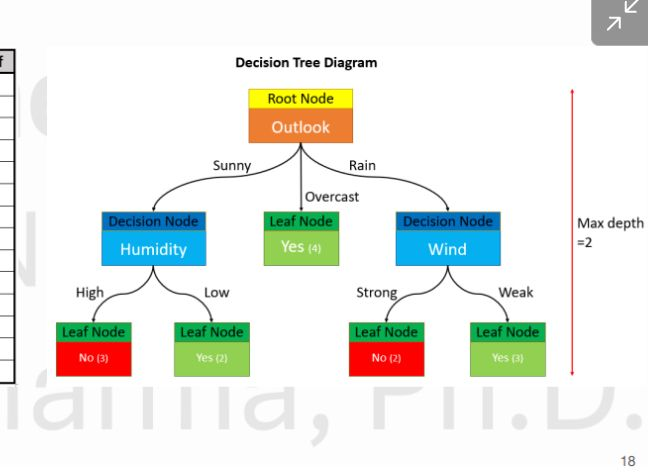

In [21]:
from IPython.display import Image, display

# Replace 'path/to/your/image.jpg' with the actual path to your image file
image_path = '/content/WhatsApp Image 2025-08-28 at 23.29.38.jpeg'

# Display the image in the notebook output
display(Image(filename=image_path))